In [1]:
#!pip install requests pandas matplotlib

Fetching data for USDJPY=X from 2020-01-01 to 2024-12-31...
✅ Fetched 1304 rows
✅ Cleaned shapes: X=(1279, 5), y=(1279,)

--- Tuning Model ---

Testing RSI period = 10
Best F1 = 0.5752 | Params = {'svm__C': 10, 'svm__kernel': 'linear'}

Testing RSI period = 14
Best F1 = 0.5825 | Params = {'svm__C': 10, 'svm__kernel': 'linear'}

Testing RSI period = 20
Best F1 = 0.6101 | Params = {'svm__C': 1, 'svm__kernel': 'linear'}

=== FINAL MODEL ===
Best Parameters: {'svm__C': 1, 'svm__kernel': 'linear', 'rsi_timeperiod': 20}
Best F1 Score: 0.6101

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.53      0.55      0.54       546
           1       0.64      0.62      0.63       710

    accuracy                           0.59      1256
   macro avg       0.59      0.59      0.59      1256
weighted avg       0.59      0.59      0.59      1256


--- Plotting Chart with Signals ---
⚠️ Chart error: x and y must be the same size

--- Running Back

/tmp/ipykernel_5501/2014926025.py:147: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  data['equity'].iloc[0] = initial_capital


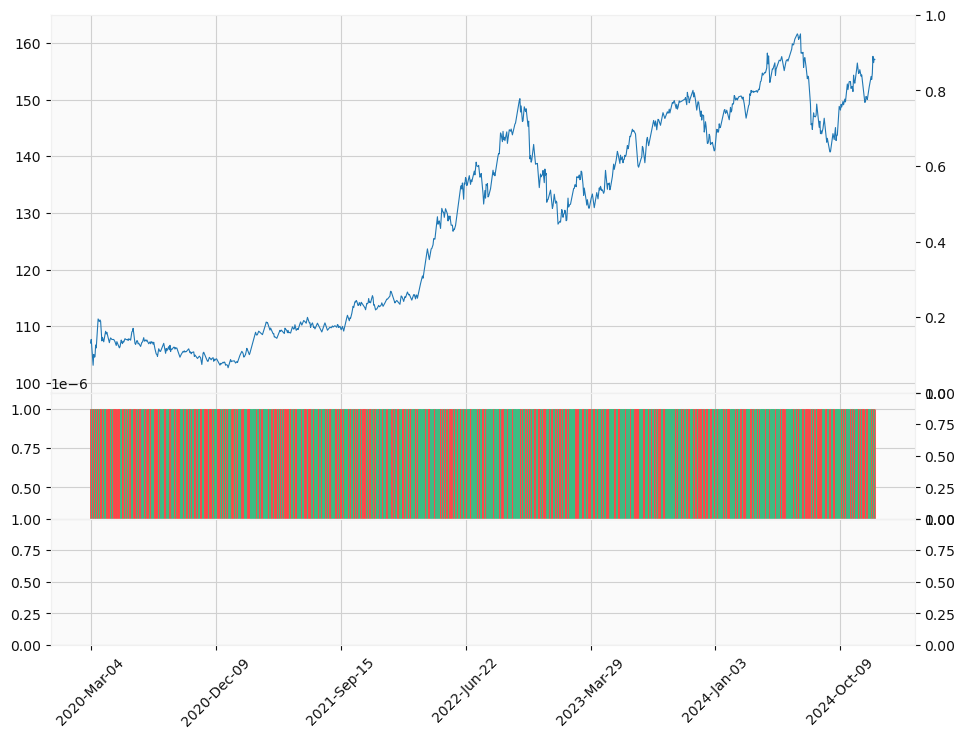

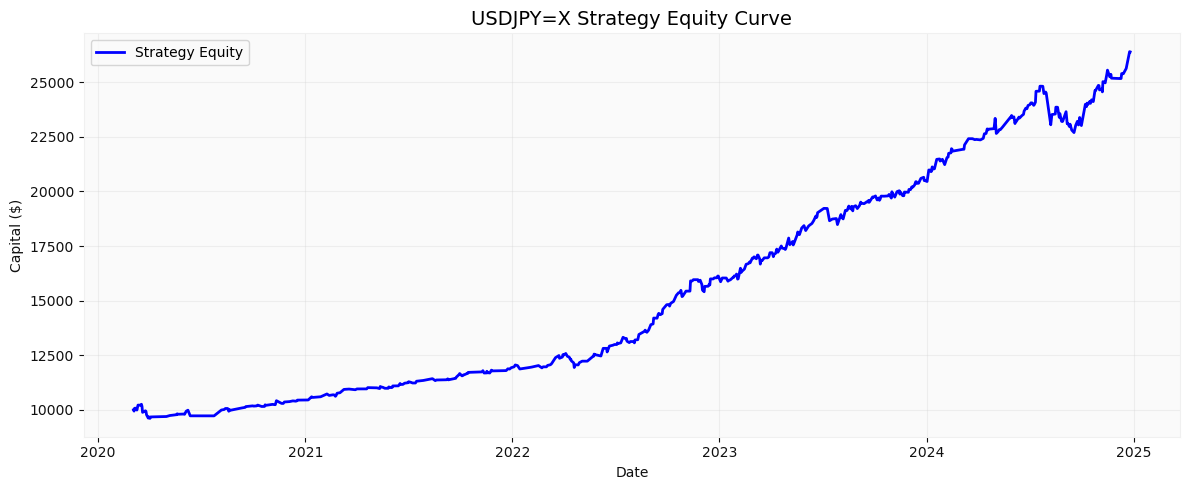


✅ Model & Signals Ready!
👉 For real trading, use: final_model.predict_proba(new_features) to get live signals


In [2]:
import pandas as pd
import numpy as np
import yfinance as yf
import talib
import mplfinance as mpf
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import classification_report


# ----------------------
# ⚙️ CONFIG SWITCHES
# ----------------------
RUN_BACKTEST = True          # Set to False to skip backtesting
PLOT_EQUITY_CURVE = True     # Only works if RUN_BACKTEST = True
PLOT_PRICE_WITH_SIGNALS = True


# ----------------------
# 1. Feature Engineering Class
# ----------------------
class FeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self, timeperiod=14):
        self.timeperiod = timeperiod

    def fit(self, X, y=None):
        return self

    def transform(self, df):
        df_features = df.copy()

        close = np.asarray(df_features['Close']).ravel()
        high = np.asarray(df_features['High']).ravel()
        low = np.asarray(df_features['Low']).ravel()
        volume = np.asarray(df_features['Volume']).ravel()

        # Technical indicators
        df_features['MA20'] = talib.SMA(close, timeperiod=20)
        df_features['ATR'] = talib.ATR(high, low, close, timeperiod=14)
        df_features['RSI'] = talib.RSI(close, timeperiod=self.timeperiod)
        df_features['CCI'] = talib.CCI(high, low, close, timeperiod=20)

        # Changes
        df_features['PriceChange'] = np.append(np.nan, np.diff(close) / close[:-1])
        df_features['VolChange'] = np.append(np.nan, np.diff(volume) / volume[:-1])

        # Lagged features
        for lag in [1, 2, 3]:
            df_features[f'RSI_lag{lag}'] = df_features['RSI'].shift(lag)
            df_features[f'VolChange_lag{lag}'] = df_features['VolChange'].shift(lag)

        feature_cols = [
            'MA20', 'ATR', 'RSI', 'CCI', 'PriceChange', 'VolChange',
            'RSI_lag1', 'RSI_lag2', 'RSI_lag3',
            'VolChange_lag1', 'VolChange_lag2', 'VolChange_lag3'
        ]
        return df_features[feature_cols]


# ----------------------
# 2. Data Preparation
# ----------------------
def prepare_forex_dataset(ticker, start, end, max_feature_lookback=20, max_label_lookahead=3, max_lag=3):
    print(f"Fetching data for {ticker} from {start} to {end}...")

    try:
        df = yf.download(ticker, start=start, end=end, progress=False)
        if df.empty:
            print("❌ No data retrieved.")
            return None, None

        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)

        df = df[['Open', 'High', 'Low', 'Close', 'Volume']].copy()
        df.sort_index(inplace=True)
        df['Volume'] = df['Volume'].replace(0, 1e-6)  # Fix zero volume for Forex

    except Exception as e:
        print(f"❌ Error fetching data: {e}")
        return None, None

    print(f"✅ Fetched {len(df)} rows")

    close = np.asarray(df['Close']).ravel()
    future_return = pd.Series(close).pct_change(max_label_lookahead).shift(-max_label_lookahead).values
    df['future_return'] = future_return
    df['label'] = np.where(future_return > 0, 1, 0)

    required_min_len = max_feature_lookback + max_lag + max_label_lookahead
    if len(df) < required_min_len:
        print(f"❌ Need at least {required_min_len} rows, got {len(df)}")
        return None, None

    temp_sma = talib.SMA(close, timeperiod=max_feature_lookback + max_lag)
    first_valid_idx = pd.Series(temp_sma, index=df.index).first_valid_index()
    if first_valid_idx is None:
        print("❌ Could not determine valid start index")
        return None, None

    df_clean = df.loc[first_valid_idx:].dropna(subset=['future_return', 'label']).copy()
    y = df_clean['label'].astype(int)
    X_raw = df_clean.drop(columns=['label', 'future_return'])

    print(f"✅ Cleaned shapes: X={X_raw.shape}, y={y.shape}")
    return X_raw, y


# ----------------------
# 3. Generate Buy/Sell Signals
# ----------------------
def generate_signals(model, X_features, threshold=0.5):
    """
    1 = Buy / Go Long
    -1 = Sell / Go Short
    0 = Hold / Flat
    """
    proba = model.predict_proba(X_features)[:, 1]
    signal = np.zeros(len(proba))
    signal[proba > threshold] = 1
    signal[proba < (1 - threshold)] = -1
    return pd.Series(signal, index=X_features.index, name='signal')


# ----------------------
# 4. Backtesting Engine
# ----------------------
def backtest(df_price, signals, initial_capital=10000, trade_size=1.0, fee_pct=0.0002):
    """
    Simple long/short backtest with transaction fee
    """
    data = df_price.copy()
    data['signal'] = signals
    data['position'] = data['signal'].shift(1).fillna(0)  # Enter next bar
    data['returns'] = data['Close'].pct_change().fillna(0)

    # Apply fee only when position changes
    data['trade'] = data['position'].diff().abs()
    data['net_returns'] = data['position'] * data['returns'] - data['trade'] * fee_pct

    # Equity curve
    data['equity'] = initial_capital * (1 + data['net_returns']).cumprod()
    data['equity'].iloc[0] = initial_capital

    # Metrics
    total_return = (data['equity'].iloc[-1] / initial_capital) - 1
    buy_hold_return = (data['Close'].iloc[-1] / data['Close'].iloc[0]) - 1
    running_max = data['equity'].cummax()
    drawdown = (data['equity'] - running_max) / running_max
    max_drawdown = drawdown.min()
    num_trades = data['trade'].sum()
    win_rate = (data['net_returns'][data['net_returns'] != 0] > 0).mean() if num_trades > 0 else 0

    metrics = {
        'Initial Capital': f"${initial_capital:,.2f}",
        'Final Equity': f"${data['equity'].iloc[-1]:,.2f}",
        'Total Strategy Return': f"{total_return:.2%}",
        'Buy & Hold Return': f"{buy_hold_return:.2%}",
        'Max Drawdown': f"{max_drawdown:.2%}",
        'Number of Trades': f"{int(num_trades)}",
        'Win Rate': f"{win_rate:.2%}"
    }

    return data, metrics


# ----------------------
# 5. Plot Functions
# ----------------------
def plot_with_signals(df, signals, title="Price & Trading Signals", rsi_period=14):
    df_plot = df.copy()
    close = np.asarray(df_plot['Close']).ravel()
    df_plot['RSI'] = talib.RSI(close, timeperiod=rsi_period)

    buy_points = df_plot.loc[signals[signals == 1].index, 'Close']
    sell_points = df_plot.loc[signals[signals == -1].index, 'Close']

    addplots = [
        mpf.make_addplot(buy_points, type='scatter', marker='^', color='g', markersize=10, panel=0, label='Buy'),
        mpf.make_addplot(sell_points, type='scatter', marker='v', color='r', markersize=10, panel=0, label='Sell'),
        mpf.make_addplot(df_plot['RSI'], panel=2, color='purple', ylabel='RSI')
    ]

    plot_type = 'candle' if len(df_plot) < 800 else 'line'

    mpf.plot(
        df_plot,
        type=plot_type,
        volume=True,
        addplot=addplots,
        title=title,
        style='yahoo',
        figsize=(12, 9),
        panel_ratios=(3, 1, 1),
        warn_too_much_data=2000
    )


def plot_equity_curve(backtest_data, title="Strategy Equity Curve"):
    plt.figure(figsize=(12, 5))
    plt.plot(backtest_data['equity'], label='Strategy Equity', color='blue', linewidth=2)
    plt.title(title, fontsize=14)
    plt.xlabel('Date')
    plt.ylabel('Capital ($)')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


# ----------------------
# Main Execution
# ----------------------
if __name__ == "__main__":
    # --- Trading Settings ---
    FOREX_PAIR = "USDJPY=X"   # Change to "EURJPY=X" or "GBPJPY=X"
    START_DATE = "2020-01-01"
    END_DATE = "2024-12-31"
    INITIAL_CAPITAL = 10000
    SIGNAL_THRESHOLD = 0.55   # Adjust for more/less signals

    # --- Load Data ---
    X_raw, y = prepare_forex_dataset(FOREX_PAIR, START_DATE, END_DATE)

    if X_raw is not None and y is not None:
        print("\n--- Tuning Model ---")
        best_score = -np.inf
        best_params = {}
        timeperiods = [10, 14, 20]

        model = Pipeline([
            ('scaler', StandardScaler()),
            ('svm', SVC(probability=True, class_weight='balanced', random_state=42))
        ])

        param_grid = {
            'svm__C': [0.1, 1, 10],
            'svm__kernel': ['linear', 'rbf']
        }

        tscv = TimeSeriesSplit(n_splits=5)

        for tp in timeperiods:
            print(f"\nTesting RSI period = {tp}")
            fe = FeatureEngineer(timeperiod=tp)
            X_feat = fe.transform(X_raw)
            combined = pd.concat([X_feat, y], axis=1).dropna()
            if combined.empty:
                continue
            X_clean, y_clean = combined.drop(columns=['label']), combined['label']

            grid = GridSearchCV(model, param_grid, cv=tscv, scoring='f1', n_jobs=-1, verbose=0)
            grid.fit(X_clean, y_clean)
            print(f"Best F1 = {grid.best_score_:.4f} | Params = {grid.best_params_}")

            if grid.best_score_ > best_score:
                best_score = grid.best_score_
                best_params = grid.best_params_.copy()
                best_params['rsi_timeperiod'] = tp

        # --- Final Model ---
        print("\n=== FINAL MODEL ===")
        print(f"Best Parameters: {best_params}")
        print(f"Best F1 Score: {best_score:.4f}")

        best_tp = best_params['rsi_timeperiod']
        svm_args = {k.replace('svm__', ''): v for k, v in best_params.items() if k.startswith('svm__')}

        fe_final = FeatureEngineer(timeperiod=best_tp)
        X_final = fe_final.transform(X_raw)
        data_final = pd.concat([X_final, y], axis=1).dropna()
        X_model, y_model = data_final.drop(columns=['label']), data_final['label']

        final_model = Pipeline([
            ('scaler', StandardScaler()),
            ('svm', SVC(probability=True, class_weight='balanced', random_state=42, **svm_args))
        ])
        final_model.fit(X_model, y_model)

        print("\n--- Classification Report ---")
        print(classification_report(y_model, final_model.predict(X_model)))

        # --- Generate Signals ---
        signals = generate_signals(final_model, X_model, threshold=SIGNAL_THRESHOLD)

        # --- Plot Price with Signals ---
        if PLOT_PRICE_WITH_SIGNALS:
            print("\n--- Plotting Chart with Signals ---")
            try:
                plot_with_signals(
                    X_raw.loc[X_model.index],
                    signals,
                    title=f"{FOREX_PAIR} | Buy/Sell Signals",
                    rsi_period=best_tp
                )
            except Exception as e:
                print(f"⚠️ Chart error: {e}")

        # --- Backtest ---
        if RUN_BACKTEST:
            print("\n--- Running Backtest ---")
            backtest_df, metrics = backtest(
                df_price=X_raw.loc[X_model.index],
                signals=signals,
                initial_capital=INITIAL_CAPITAL
            )

            print("\n=== BACKTEST SUMMARY ===")
            for k, v in metrics.items():
                print(f"{k}: {v}")

            # --- Plot Equity Curve ---
            if PLOT_EQUITY_CURVE:
                print("\n--- Plotting Equity Curve ---")
                try:
                    plot_equity_curve(backtest_df, title=f"{FOREX_PAIR} Strategy Equity Curve")
                except Exception as e:
                    print(f"⚠️ Equity plot error: {e}")

        # --- Ready for Real Trading ---
        print("\n✅ Model & Signals Ready!")
        print("👉 For real trading, use: final_model.predict_proba(new_features) to get live signals")

    else:
        print("❌ Execution failed.")